In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## U-Net++ Architecture
Implementing nested U-Net with dense skip connections and deep supervision.

In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_rate=0.15):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate)
        )
    
    def forward(self, x):
        return self.conv(x)

class UNetPP(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, filters=(32,64,128,256,512), dropout_rates=None):
        super().__init__()
        
        if dropout_rates is None:
            # Consistent dropout matching SegFormer (0.15)
            dropout_rates = {
                'encoder': [0.0, 0.0, 0.0, 0.0, 0.15],
                'decoder': [0.15, 0.15, 0.15, 0.15],
                'skip': 0.0,
                'final': 0.0
            }
        
        self.dropout_rates = dropout_rates
        f0, f1, f2, f3, f4 = filters
        
        # Encoder path (downsampling)
        self.conv0_0 = ConvBlock(in_ch, f0, dropout_rates['encoder'][0])
        self.conv1_0 = ConvBlock(f0, f1, dropout_rates['encoder'][1])
        self.conv2_0 = ConvBlock(f1, f2, dropout_rates['encoder'][2])
        self.conv3_0 = ConvBlock(f2, f3, dropout_rates['encoder'][3])
        self.conv4_0 = ConvBlock(f3, f4, dropout_rates['encoder'][4])
        
        self.pool = nn.MaxPool2d(2)
        
        # Nested decoder path
        self.conv0_1 = ConvBlock(f0+f1, f0, dropout_rates['decoder'][0])
        self.conv1_1 = ConvBlock(f1+f2, f1, dropout_rates['decoder'][1])
        self.conv2_1 = ConvBlock(f2+f3, f2, dropout_rates['decoder'][2])
        self.conv3_1 = ConvBlock(f3+f4, f3, dropout_rates['decoder'][3])
        
        self.conv0_2 = ConvBlock(f0*2+f1, f0, dropout_rates['decoder'][0])
        self.conv1_2 = ConvBlock(f1*2+f2, f1, dropout_rates['decoder'][1])
        self.conv2_2 = ConvBlock(f2*2+f3, f2, dropout_rates['decoder'][2])
        
        self.conv0_3 = ConvBlock(f0*3+f1, f0, dropout_rates['decoder'][0])
        self.conv1_3 = ConvBlock(f1*3+f2, f1, dropout_rates['decoder'][1])
        
        self.conv0_4 = ConvBlock(f0*4+f1, f0, dropout_rates['decoder'][0])
        
        # Upsampling
        self.up1 = nn.ConvTranspose2d(f1, f1, 2, stride=2)
        self.up2 = nn.ConvTranspose2d(f2, f2, 2, stride=2)
        self.up3 = nn.ConvTranspose2d(f3, f3, 2, stride=2)
        self.up4 = nn.ConvTranspose2d(f4, f4, 2, stride=2)
        
        # Final output
        self.final = nn.Conv2d(f0, out_ch, 1)
    
    def forward(self, x):
        # Encoder
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))
        
        # Nested skip connections - Level 1
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up1(x1_0)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up2(x2_0)], 1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up3(x3_0)], 1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up4(x4_0)], 1))
        
        # Nested skip connections - Level 2
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up1(x1_1)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up2(x2_1)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up3(x3_1)], 1))
        
        # Nested skip connections - Level 3
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up1(x1_2)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up2(x2_2)], 1))
        
        # Nested skip connections - Level 4
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up1(x1_3)], 1))
        
        output = self.final(x0_4)
        return output

## Dataset and Data Loading

In [3]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def find_pv01_pairs(root_dir):
    """Walk root_dir and pair every 'NAME.<ext>' image with its 'NAME_label.<ext>' mask.
    Returns {group_name: [(image_path, label_path), ...]} where group_name is the
    rooftop folder (PV01_Rooftop_Brick, PV01_Rooftop_FlatConcrete, ...)."""
    groups = {}
    for folder, _, files in sorted(os.walk(root_dir)):
        by_stem = {os.path.splitext(f)[0]: f for f in sorted(files) if f.lower().endswith(IMG_EXTS)}
        rel = os.path.relpath(folder, root_dir)
        group = rel.split(os.sep)[0]
        for stem, fname in by_stem.items():
            if stem.endswith('_label'):
                continue
            lbl = by_stem.get(stem + '_label')
            if lbl is not None:
                groups.setdefault(group, []).append((os.path.join(folder, fname), os.path.join(folder, lbl)))
    return groups

def build_pv01_splits(root_dir, val_frac=0.15, test_frac=0.15, seed=42):
    """PV01 ships without a train/val/test split, so make a fixed, seeded one.
    The split is done per rooftop folder so all three types appear in every split."""
    groups = find_pv01_pairs(root_dir)
    assert len(groups) > 0, f"No image/_label pairs found under {root_dir}"
    rng = np.random.RandomState(seed)
    train, val, test = [], [], []
    for g in sorted(groups):
        pairs = groups[g]
        idx = rng.permutation(len(pairs))
        n_test = int(round(len(pairs) * test_frac))
        n_val = int(round(len(pairs) * val_frac))
        test += [pairs[i] for i in idx[:n_test]]
        val += [pairs[i] for i in idx[n_test:n_test + n_val]]
        train += [pairs[i] for i in idx[n_test + n_val:]]
        print(f"{g}: {len(pairs)} pairs")
    return train, val, test

class PV01Dataset(Dataset):
    def __init__(self, pairs, transform=None, img_size=(256, 256)):
        self.pairs = pairs
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, label_path = self.pairs[idx]

        img = Image.open(img_path).convert('RGB').resize(self.img_size)
        label = Image.open(label_path).convert('L').resize(self.img_size, Image.NEAREST)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        # binary mask: any non-zero pixel is solar panel (works for 0/255 and 0/1 masks)
        label = torch.from_numpy((np.array(label) > 0).astype(np.float32)).unsqueeze(0)

        return img, label


## Loss Functions and Metrics

In [4]:
def dice_coef(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    denom = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        dice = dice_coef(pred, target, smooth=self.smooth)
        return 1.0 - dice

def combined_loss(logits, mask, bce_weight=0.6, dice_weight=0.4):
    bce_loss = nn.BCEWithLogitsLoss()
    bce = bce_loss(logits, mask)
    probs = torch.sigmoid(logits)
    dice = DiceLoss()(probs, mask)
    return bce_weight * bce + dice_weight * dice

@torch.no_grad()
def compute_metrics_batch(logits, masks, thresh=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thresh).float()
    preds_flat = preds.view(-1).cpu().numpy()
    masks_flat = masks.view(-1).cpu().numpy()
    
    unique_preds = np.unique(preds_flat)
    unique_masks = np.unique(masks_flat)
    
    if len(unique_preds) == 1 and len(unique_masks) == 1:
        if unique_preds[0] == unique_masks[0]:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = len(preds_flat), 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, len(preds_flat)
        else:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = 0, len(preds_flat), 0, 0
            else:
                tp, fp, fn, tn = 0, 0, len(preds_flat), 0
    else:
        cm = confusion_matrix(masks_flat, preds_flat, labels=[0,1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            if cm.shape == (1, 1):
                if unique_masks[0] == 0:
                    tn, fp, fn, tp = cm[0,0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0,0]
            else:
                tn, fp, fn, tp = 0, 0, 0, 0
    
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "iou": float(iou), "dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "acc": float(acc), "miou": float(miou)}

## Training and Validation Functions

In [5]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Train batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    train_acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, train_acc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Val batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    epoch_loss = running_loss / len(loader.dataset)
    metrics = {"loss": epoch_loss, "iou": iou, "dice": dice, "precision": precision,
               "recall": recall, "f1": f1, "acc": acc, "miou": miou,
               "confusion": np.array([[tn, fp], [fn, tp]])}
    return metrics

def train_model(model, train_loader, val_loader, num_epochs=200, learning_rate=2e-4, patience=10):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = optim.AdamW(
        [
            {"params": decay, "weight_decay": 1e-3},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, min_lr=1e-6
    )
    
    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4)
    
    train_losses = []
    val_losses = []
    val_ious = []
    val_dices = []
    train_accs = []
    val_accs = []
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        
        val_metrics = validate(model, val_loader)
        
        scheduler.step(val_metrics['loss'])
        
        print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.6f} | Val Acc: {val_metrics['acc']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        
        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
        val_ious.append(val_metrics['iou'])
        val_dices.append(val_metrics['dice'])
        train_accs.append(train_acc)
        val_accs.append(val_metrics['acc'])
        
        if val_metrics['loss'] < best_val_loss - 1e-4:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'best_unetpp_old_pv01.pth')
            print(f"Saved best model with validation loss: {best_val_loss:.6f}")
        
        if early_stopping(val_metrics['loss'], model):
            print(f'Early stopping triggered after {epoch+1} epochs')
            break
    
    return train_losses, val_losses, val_ious, val_dices, train_accs, val_accs

## Training Configuration and Execution


In [6]:
def main():
    # Hyperparameters matching SegFormer
    BATCH_SIZE = 6
    LEARNING_RATE = 2e-4
    NUM_EPOCHS = 200
    PATIENCE = 10
    IMG_SIZE = (256, 256)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # folder that contains PV01_Rooftop_Brick, PV01_Rooftop_FlatConcrete, PV01_Rooftop_SteelTile
    root_dir = '/kaggle/input/datasets/huihuiiiiiiiii/pv01dataset/PV01/PV01'
    
    train_pairs, val_pairs, test_pairs = build_pv01_splits(root_dir, val_frac=0.15, test_frac=0.15, seed=42)
    train_dataset = PV01Dataset(train_pairs, transform=transform, img_size=IMG_SIZE)
    val_dataset = PV01Dataset(val_pairs, transform=transform, img_size=IMG_SIZE)
    test_dataset = PV01Dataset(test_pairs, transform=transform, img_size=IMG_SIZE)
    
    train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    # dropout as U-Net (old): encoder block 4 = 0.1, bottleneck = 0.5, decoder = 0.15
    dropout_config = {
        'encoder': [0.0, 0.0, 0.0, 0.1, 0.5],
        'decoder': [0.15, 0.15, 0.15, 0.15],
    }
    FILTERS = (32, 64, 128, 256, 512)
    
    model = UNetPP(in_ch=3, out_ch=1, filters=FILTERS, dropout_rates=dropout_config).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    print("\nStarting U-Net++ training")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Weight Decay: 1e-3")
    print(f"Dropout: {dropout_config}")
    print(f"Threshold: 0.5")
    print(f"Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)\n")
    
    train_losses, val_losses, val_ious, val_dices, train_accs, val_accs = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE
    )
    
    return model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader

model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader = main()

PV01_Rooftop_Brick: 138 pairs
PV01_Rooftop_FlatConcrete: 413 pairs
PV01_Rooftop_SteelTile: 94 pairs
Training samples: 451
Validation samples: 97
Test samples: 97
Total parameters: 10,553,281

Starting U-Net++ training
Learning Rate: 0.0002
Weight Decay: 1e-3
Dropout: {'encoder': [0.0, 0.0, 0.0, 0.1, 0.5], 'decoder': [0.15, 0.15, 0.15, 0.15]}
Threshold: 0.5
Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)


Epoch 1/200


Val batch: 100%|██████████| 49/49 [00:03<00:00, 14.85it/s]


Train Loss: 0.495196 | Train Acc: 0.8350
Val Loss: 0.396035 | Val Acc: 0.9100 | IoU: 0.7482 | Dice: 0.8560 | F1: 0.8560
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.396035

Epoch 2/200


Val batch: 100%|██████████| 49/49 [00:02<00:00, 19.38it/s]


Train Loss: 0.406798 | Train Acc: 0.9113
Val Loss: 0.339622 | Val Acc: 0.9530 | IoU: 0.8590 | Dice: 0.9242 | F1: 0.9242
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.339622

Epoch 3/200


...

Train Loss: 0.060929 | Train Acc: 0.9819
Val Loss: 0.076507 | Val Acc: 0.9786 | IoU: 0.9294 | Dice: 0.9634 | F1: 0.9634
Learning Rate: 1.40e-04

Epoch 52/200


Val batch: 100%|██████████| 49/49 [00:02<00:00, 19.11it/s]


Train Loss: 0.049748 | Train Acc: 0.9836
Val Loss: 0.060924 | Val Acc: 0.9814 | IoU: 0.9387 | Dice: 0.9684 | F1: 0.9684
Learning Rate: 1.40e-04

Epoch 53/200


Val batch: 100%|██████████| 49/49 [00:02<00:00, 17.94it/s]

Train Loss: 0.052174 | Train Acc: 0.9838
Val Loss: 0.061422 | Val Acc: 0.9817 | IoU: 0.9400 | Dice: 0.9691 | F1: 0.9691
Learning Rate: 1.40e-04
Early stopping triggered after 53 epochs


## Visualization of Training Progress

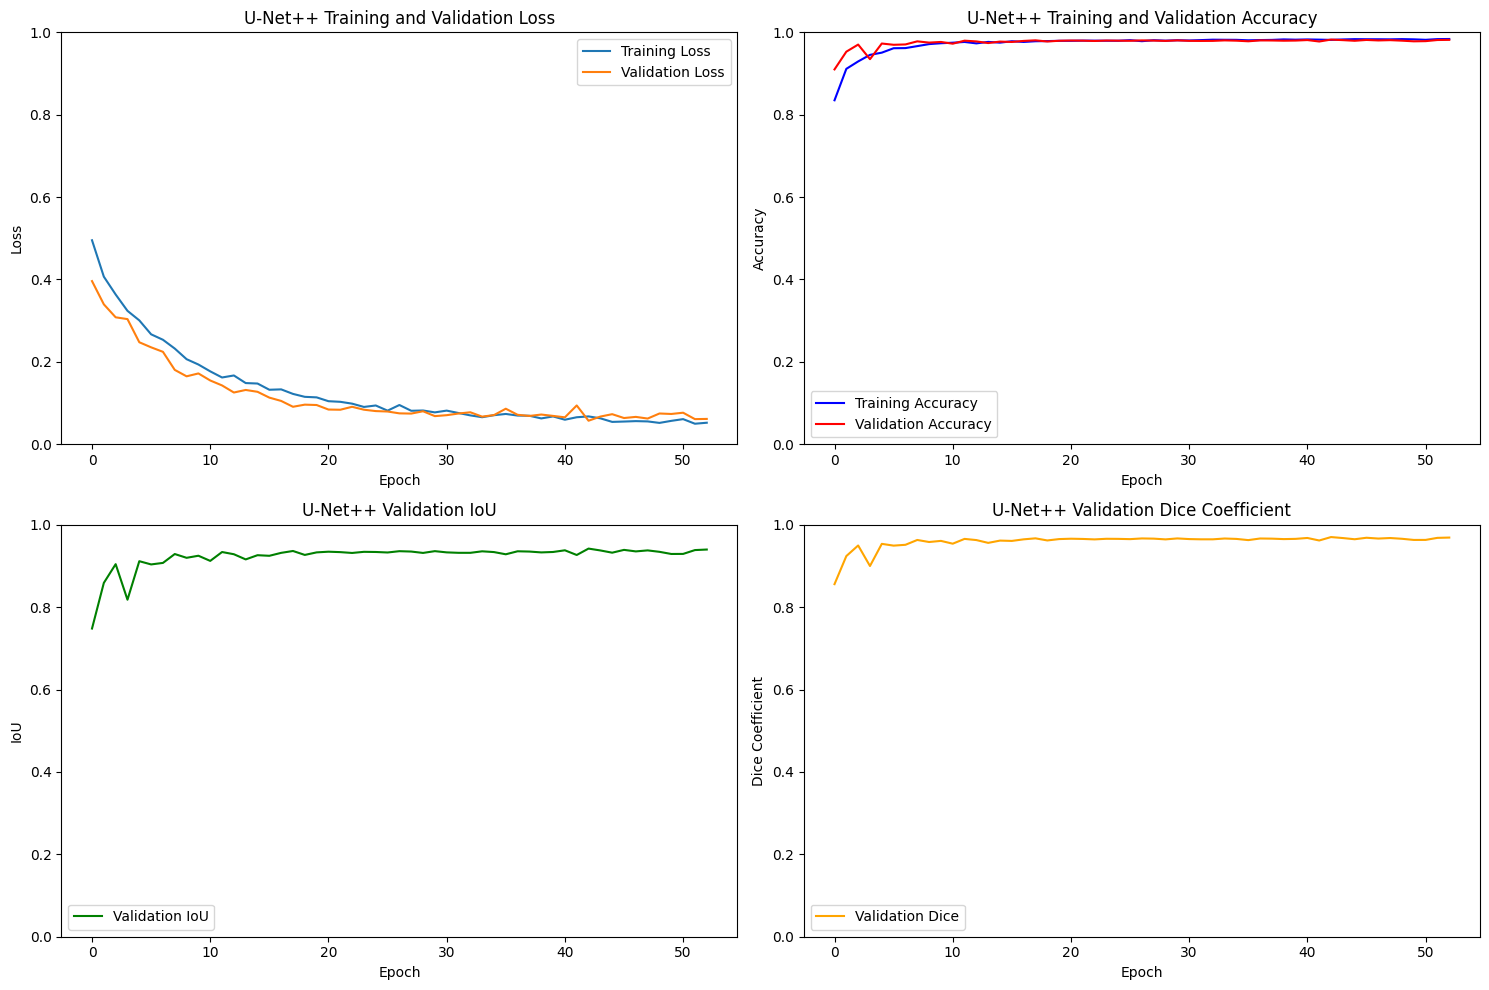

In [7]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.set_title('U-Net++ Training and Validation Loss')

ax2.plot(train_accs, label='Training Accuracy', color='blue')
ax2.plot(val_accs, label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.set_title('U-Net++ Training and Validation Accuracy')

ax3.plot(val_ious, label='Validation IoU', color='green')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('IoU')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.set_title('U-Net++ Validation IoU')

ax4.plot(val_dices, label='Validation Dice', color='orange')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Dice Coefficient')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.set_title('U-Net++ Validation Dice Coefficient')

plt.tight_layout()
plt.savefig('unetpp_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Test Evaluation

Loading best U-Net++ model for test evaluation...

Evaluating U-Net++ on test set...


Val batch: 100%|██████████| 97/97 [00:03<00:00, 26.89it/s]



U-NET++ TEST EVALUATION METRICS
Configuration: U-Net++ | dropout as U-Net (old): encoder block 4 = 0.1, bottleneck = 0.5, decoder = 0.15
Test set processed with batch_size=1
Loss:            0.060487
IoU:             0.9370
mIoU:            0.9580
Dice Coefficient: 0.9675
Accuracy:        0.9840
Precision:       0.9681
Recall:          0.9669
F1-Score:        0.9675
Confusion matrix (pixel-level):
[[4740063   49969]
 [  51879 1515081]]


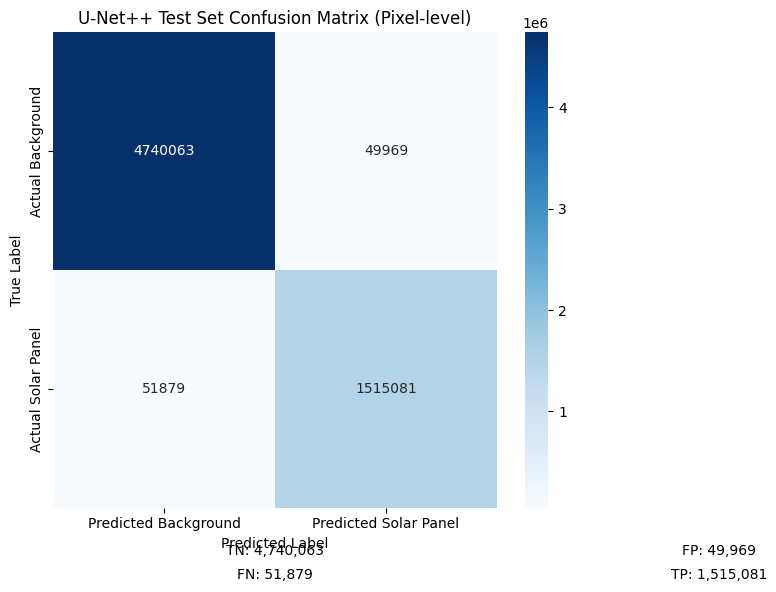

U-Net++ training and evaluation completed!


In [8]:
print("Loading best U-Net++ model for test evaluation...")
model.load_state_dict(torch.load('best_unetpp_old_pv01.pth', map_location=device))
model.to(device)

print("\nEvaluating U-Net++ on test set...")
test_metrics = validate(model, test_loader)

print("\n" + "="*50)
print("U-NET++ TEST EVALUATION METRICS")
print("Configuration: U-Net++ | dropout as U-Net (old): encoder block 4 = 0.1, bottleneck = 0.5, decoder = 0.15")
print("="*50)
print(f"Test set processed with batch_size=1")
print(f"Loss:            {test_metrics['loss']:.6f}")
print(f"IoU:             {test_metrics['iou']:.4f}")
print(f"mIoU:            {test_metrics['miou']:.4f}")
print(f"Dice Coefficient: {test_metrics['dice']:.4f}")
print(f"Accuracy:        {test_metrics['acc']:.4f}")
print(f"Precision:       {test_metrics['precision']:.4f}")
print(f"Recall:          {test_metrics['recall']:.4f}")
print(f"F1-Score:        {test_metrics['f1']:.4f}")
print("Confusion matrix (pixel-level):")
print(test_metrics["confusion"])
print("="*50)

plt.figure(figsize=(8, 6))
cm = test_metrics["confusion"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Background', 'Predicted Solar Panel'],
            yticklabels=['Actual Background', 'Actual Solar Panel'])
plt.title('U-Net++ Test Set Confusion Matrix (Pixel-level)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.text(0.5, -0.1, f'TN: {cm[0,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.1, f'FP: {cm[0,1]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(0.5, -0.15, f'FN: {cm[1,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.15, f'TP: {cm[1,1]:,}', ha='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('unetpp_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("U-Net++ training and evaluation completed!")


## Test the model on images

PV01_Rooftop_Brick: 138 pairs
PV01_Rooftop_FlatConcrete: 413 pairs
PV01_Rooftop_SteelTile: 94 pairs


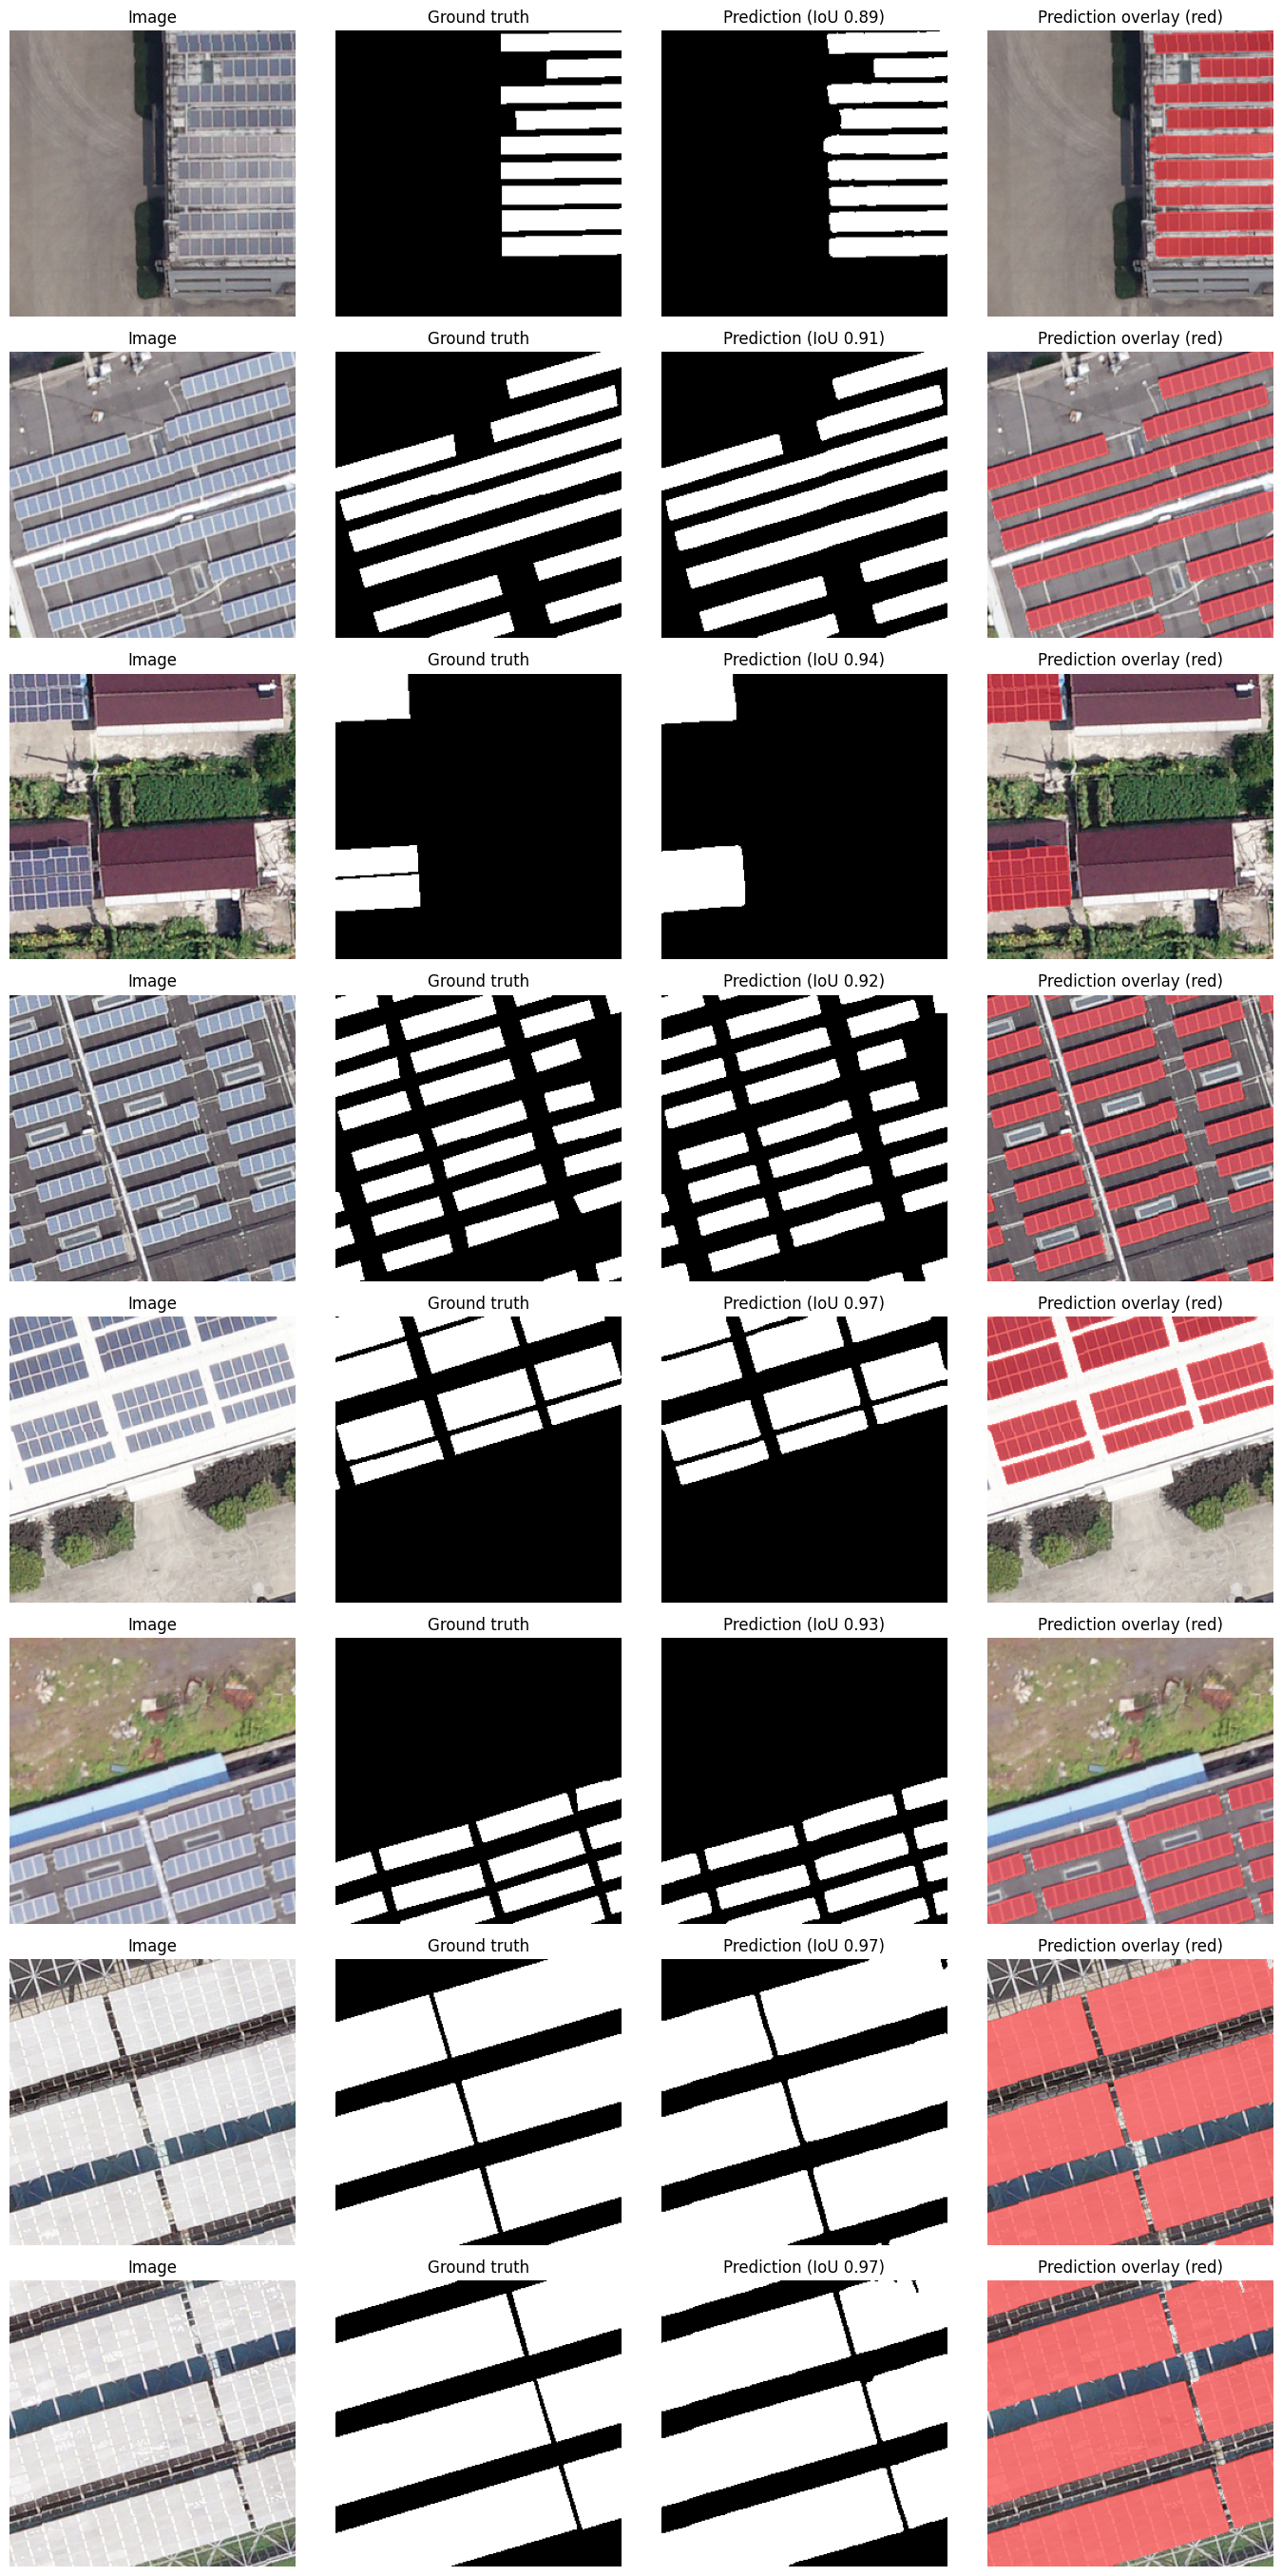

In [9]:
import random

root_dir = '/kaggle/input/datasets/huihuiiiiiiiii/pv01dataset/PV01/PV01'
IMG_SIZE = (256, 256)
FILTERS = (32, 64, 128, 256, 512)
DROPOUT = {'encoder': [0.0, 0.0, 0.0, 0.1, 0.5], 'decoder': [0.15, 0.15, 0.15, 0.15]}
CKPT = 'best_unetpp_old_pv01.pth'

# rebuild the same test set (fixed seed) and load the best checkpoint
_, _, test_pairs = build_pv01_splits(root_dir, val_frac=0.15, test_frac=0.15, seed=42)
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_ds = PV01Dataset(test_pairs, transform=tf, img_size=IMG_SIZE)

net = UNetPP(in_ch=3, out_ch=1, filters=FILTERS, dropout_rates=DROPOUT).to(device)
net.load_state_dict(torch.load(CKPT, map_location=device))
net.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_predictions(n=8, seed=0, thresh=0.5):
    random.seed(seed)
    idxs = random.sample(range(len(test_ds)), n)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    for r, i in enumerate(idxs):
        img, gt = test_ds[i]
        with torch.no_grad():
            prob = torch.sigmoid(net(img.unsqueeze(0).to(device)))[0, 0].cpu()
        pred = (prob >= thresh).float()

        rgb = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        gt_np, pred_np = gt[0].numpy(), pred.numpy()

        inter = (gt_np * pred_np).sum()
        union = gt_np.sum() + pred_np.sum() - inter
        iou = inter / union if union > 0 else float('nan')

        overlay = rgb.copy()
        overlay[pred_np > 0] = 0.5 * overlay[pred_np > 0] + 0.5 * np.array([1, 0, 0])

        axes[r, 0].imshow(rgb);                  axes[r, 0].set_title("Image")
        axes[r, 1].imshow(gt_np, cmap='gray');   axes[r, 1].set_title("Ground truth")
        axes[r, 2].imshow(pred_np, cmap='gray'); axes[r, 2].set_title(f"Prediction (IoU {iou:.2f})")
        axes[r, 3].imshow(overlay);              axes[r, 3].set_title("Prediction overlay (red)")
        for a in axes[r]: a.axis('off')
    plt.tight_layout()
    plt.savefig('predictions_unetpp_old.png', dpi=200, bbox_inches='tight')
    plt.show()

show_predictions(n=8, seed=0)
